In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%pip install python-docx openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 13.0 MB/s eta 0:00:00


In [4]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from docx import Document
from docx.shared import Inches

warnings.filterwarnings("ignore")

In [23]:
PROJECT_PATH = Path('/content/drive/MyDrive/2026-1/언어심리학/Project Materials')
DATA_PATH = PROJECT_PATH / 'KLP_DB_final.xlsx'   
SHEET_NAME = "KLP_DB_final"                

OUT_DIR = PROJECT_PATH / 'fig_and_tab'
OUT_DIR.mkdir(exist_ok=True)

RT_MIN = 300
RT_MAX = 1500

FULL_REQUIRED_COLS = ["Lexicality", "Freq", "MRT", "MHIT", "syltkn1", "syltkn2"]

LOW_MIN, LOW_MAX = 11, 50
MED_MIN, MED_MAX = 51, 200
HIGH_MIN = 201

In [6]:
def require_columns(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}\nAvailable columns: {list(df.columns)}")

def to_numeric_safe(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def zscore_series(s):
    s = pd.to_numeric(s, errors="coerce")
    return (s - s.mean()) / s.std(ddof=0)

def format_p(p):
    if pd.isna(p):
        return ""
    if p < .001:
        return "< .001"
    return f"{p:.3f}".replace("0.", ".")

def format_num(x, digits=3):
    if pd.isna(x):
        return ""
    return f"{x:.{digits}f}"

def add_constant_and_fit(df, dv, predictors, robust=True):
    """
    Fits OLS model. Predictors should already exist in df.
    Returns regular model and robust-HC3 model.
    """
    model_df = df[[dv] + predictors].dropna().copy()
    X = sm.add_constant(model_df[predictors], has_constant="add")
    y = model_df[dv]
    regular = sm.OLS(y, X).fit()
    robust_model = regular.get_robustcov_results(cov_type="HC3") if robust else regular
    return regular, robust_model, model_df
def get_param_table(regular_model, robust_model, predictor_name):
    """
    Extract coefficient, SE, CI, p for one predictor.
    Uses robust model for coefficient inference.
    """
    names = list(regular_model.params.index)
    idx = names.index(predictor_name)

    coef = robust_model.params[idx]
    se = robust_model.bse[idx]
    p = robust_model.pvalues[idx]
    ci_low, ci_high = robust_model.conf_int()[idx]

    return coef, se, ci_low, ci_high, p

def partial_r_from_t(t_value, df_resid):
    return np.sign(t_value) * np.sqrt((t_value ** 2) / ((t_value ** 2) + df_resid))

def compute_vif_table(df, predictors):
    model_df = df[predictors].dropna().copy()
    X = sm.add_constant(model_df, has_constant="add")

    rows = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        vif = variance_inflation_factor(X.values, i)
        rows.append({
            "Predictor": col,
            "Tolerance": 1 / vif if vif != 0 else np.nan,
            "VIF": vif
        })
    return pd.DataFrame(rows)

def hierarchical_mrt_table(df, dv="MRT"):
    """
    Full hierarchical model:
    Step 1: z_LogFreq
    Step 2: z_LogFreq + z_syltkn1
    Step 3: z_LogFreq + z_syltkn1 + z_syltkn2
    """
    d = df.copy()
    d["z_LogFreq"] = zscore_series(d["LogFreq"])
    d["z_syltkn1"] = zscore_series(d["syltkn1"])
    d["z_syltkn2"] = zscore_series(d["syltkn2"])

    steps = [
        ("1", ["z_LogFreq"], "z_LogFreq"),
        ("2", ["z_LogFreq", "z_syltkn1"], "z_syltkn1"),
        ("3", ["z_LogFreq", "z_syltkn1", "z_syltkn2"], "z_syltkn2")
    ]

    rows = []
    prev_r2 = None

    for step, predictors, focal in steps:
        regular, robust_model, model_df = add_constant_and_fit(d, dv, predictors, robust=True)
        names = list(regular.params.index)
        idx = names.index(focal)

        coef = robust_model.params[idx]
        se = robust_model.bse[idx]
        tval = robust_model.tvalues[idx]
        pval = robust_model.pvalues[idx]

        r2 = regular.rsquared
        delta_r2 = r2 if prev_r2 is None else r2 - prev_r2
        prev_r2 = r2

        rows.append({
            "Step": step,
            "Focal predictor added": focal.replace("z_", ""),
            "N": int(regular.nobs),
            "β per SD": coef,
            "Robust SE": se,
            "t": tval,
            "p": pval,
            "R²": r2,
            "ΔR²": delta_r2
        })

    out = pd.DataFrame(rows)
    return out

def final_syltkn2_effect(df, dv="MRT", mhit_subceiling=False):
    """
    Within a given df, fit final hierarchical model:
    DV ~ z_LogFreq + z_syltkn1 + z_syltkn2
    Return syltkn2 coefficient, CI, p, partial r.
    """
    d = df.copy()

    if mhit_subceiling:
        d = d[d["MHIT"] < 100].copy()

    d["z_LogFreq"] = zscore_series(d["LogFreq"])
    d["z_syltkn1"] = zscore_series(d["syltkn1"])
    d["z_syltkn2"] = zscore_series(d["syltkn2"])

    predictors = ["z_LogFreq", "z_syltkn1", "z_syltkn2"]
    regular, robust_model, model_df = add_constant_and_fit(d, dv, predictors, robust=True)

    names = list(regular.params.index)
    idx = names.index("z_syltkn2")

    coef = robust_model.params[idx]
    se = robust_model.bse[idx]
    tval = robust_model.tvalues[idx]
    pval = robust_model.pvalues[idx]
    ci_low, ci_high = robust_model.conf_int()[idx]
    pr = partial_r_from_t(tval, regular.df_resid)

    return {
        "N": int(regular.nobs),
        "β per SD": coef,
        "Robust SE": se,
        "95% CI low": ci_low,
        "95% CI high": ci_high,
        "p": pval,
        "partial r": pr,
        "R² final model": regular.rsquared
    }

def compare_nested_interaction(df):
    """
    Tests LogFreq x syltkn2 interaction.
    Uses centered standardized variables.
    Model without interaction vs. with interaction.
    """
    d = df.copy()
    d["z_LogFreq"] = zscore_series(d["LogFreq"])
    d["z_syltkn1"] = zscore_series(d["syltkn1"])
    d["z_syltkn2"] = zscore_series(d["syltkn2"])
    d["LogFreq_x_syltkn2"] = d["z_LogFreq"] * d["z_syltkn2"]

    base_predictors = ["z_LogFreq", "z_syltkn1", "z_syltkn2"]
    int_predictors = base_predictors + ["LogFreq_x_syltkn2"]

    base_regular, _, base_df = add_constant_and_fit(d, "MRT", base_predictors, robust=True)
    int_regular, int_robust, int_df = add_constant_and_fit(d, "MRT", int_predictors, robust=True)

    # Classic nested F test for added interaction.
    f_stat, f_p, df_diff = int_regular.compare_f_test(base_regular)

    coef, se, ci_low, ci_high, p_robust = get_param_table(
        int_regular, int_robust, "LogFreq_x_syltkn2"
    )

    return pd.DataFrame([{
        "Model comparison": "Base model vs. + LogFreq × syltkn2",
        "Interaction predictor": "LogFreq × syltkn2",
        "N": int(int_regular.nobs),
        "β": coef,
        "Robust SE": se,
        "95% CI low": ci_low,
        "95% CI high": ci_high,
        "ΔF": f_stat,
        "df difference": int(df_diff),
        "p for ΔF": f_p,
        "robust p for interaction coefficient": p_robust,
        "Verdict": "n.s." if f_p >= .05 else "significant"
    }])

def assign_theory_band(df):
    d = df.copy()
    d["FreqBand"] = np.nan
    d.loc[(d["Freq"] >= LOW_MIN) & (d["Freq"] <= LOW_MAX), "FreqBand"] = "Low (11–50)"
    d.loc[(d["Freq"] >= MED_MIN) & (d["Freq"] <= MED_MAX), "FreqBand"] = "Medium (51–200)"
    d.loc[(d["Freq"] >= HIGH_MIN), "FreqBand"] = "High (200+)"
    return d

def band_analysis_table(df, dv="MRT", mhit_subceiling=False):
    d = assign_theory_band(df)
    rows = []

    for band in ["Low (11–50)", "Medium (51–200)", "High (200+)"]:
        bd = d[d["FreqBand"] == band].copy()
        result = final_syltkn2_effect(bd, dv=dv, mhit_subceiling=mhit_subceiling)

        rows.append({
            "Band": band,
            "DV": dv,
            **result
        })

    return pd.DataFrame(rows)

def quartile_analysis_table(df):
    d = df.copy()
    d["Quartile"] = pd.qcut(d["Freq"], q=4, labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])

    rows = []
    for q in ["Q1 lowest", "Q2", "Q3", "Q4 highest"]:
        qd = d[d["Quartile"] == q].copy()
        result = final_syltkn2_effect(qd, dv="MRT", mhit_subceiling=False)

        rows.append({
            "Quartile": q,
            "Freq min": qd["Freq"].min(),
            "Freq max": qd["Freq"].max(),
            **result
        })

    return pd.DataFrame(rows)

def save_df_files(df, name):
    """
    Saves each table as CSV and returns clean copy.
    """
    safe_name = name.lower().replace(" ", "_").replace("/", "_")
    df.to_csv(OUT_DIR / f"{safe_name}.csv", index=False, encoding="utf-8-sig")
    return df

def add_df_to_docx(document, title, df):
    document.add_heading(title, level=2)

    table = document.add_table(rows=1, cols=len(df.columns))
    table.style = "Table Grid"

    hdr_cells = table.rows[0].cells
    for j, col in enumerate(df.columns):
        hdr_cells[j].text = str(col)

    for _, row in df.iterrows():
        cells = table.add_row().cells
        for j, col in enumerate(df.columns):
            val = row[col]
            if isinstance(val, float):
                if "p" in str(col).lower():
                    text = format_p(val)
                else:
                    text = format_num(val, 3)
            else:
                text = "" if pd.isna(val) else str(val)
            cells[j].text = text

    document.add_paragraph("")

def clean_for_display(df):
    """
    Adds formatted p-values and rounded numeric output.
    Keeps original raw CSV saved separately.
    """
    out = df.copy()
    for col in out.columns:
        if pd.api.types.is_numeric_dtype(out[col]):
            if "p" in col.lower():
                out[col] = out[col].apply(format_p)
            elif "N" == col or "df difference" == col:
                out[col] = out[col].astype("Int64")
            else:
                out[col] = out[col].round(3)
    return out


In [7]:
df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
require_columns(df_raw, FULL_REQUIRED_COLS)

df = df_raw.copy()
df = to_numeric_safe(df, ["Lexicality", "Freq", "MRT", "MHIT", "syltkn1", "syltkn2"])

# Real words only
df_words_initial = df[df["Lexicality"] == 1].copy()

# Apply valid frequency and log transform
df_words_initial = df_words_initial[df_words_initial["Freq"] > 0].copy()
df_words_initial["LogFreq"] = np.log(df_words_initial["Freq"])

# Main complete-case sample
key_vars = ["Freq", "LogFreq", "MRT", "MHIT", "syltkn1", "syltkn2"]
df_words = df_words_initial.dropna(subset=key_vars).copy()

# Optional RT boundary audit if trial-level values are somehow present as item means.
# For item-level MRT, do not drop based on MRT unless your project explicitly does this.
df_restricted = df_words[(df_words["Freq"] >= 15) & (df_words["Freq"] <= 50)].copy()

df_banded = assign_theory_band(df_words)

print("Loaded raw rows:", len(df_raw))
print("Real words after Lexicality == 1 and Freq > 0:", len(df_words_initial))
print("Complete-case full sample:", len(df_words))
print("Restricted Freq 15–50 sample:", len(df_restricted))
print(df_banded["FreqBand"].value_counts(dropna=False))

Loaded raw rows: 9928
Real words after Lexicality == 1 and Freq > 0: 4566
Complete-case full sample: 4565
Restricted Freq 15–50 sample: 1778
FreqBand
Low (11–50)        1781
Medium (51–200)    1601
High (200+)        1179
NaN                   4
Name: count, dtype: int64


## Table 1. Sample Construction

In [8]:
table1 = pd.DataFrame([
    {"Step": "Raw dataset", "Criterion": "All rows in source file", "N": len(df_raw)},
    {"Step": "Real-word sample", "Criterion": "Lexicality == 1 and Freq > 0", "N": len(df_words_initial)},
    {"Step": "Full analysis sample", "Criterion": "Complete cases for Freq, LogFreq, MRT, MHIT, syltkn1, syltkn2", "N": len(df_words)},
    {"Step": "Restricted replication sample", "Criterion": "Freq 15–50 complete cases", "N": len(df_restricted)},
    {"Step": "Low band", "Criterion": "Freq 11–50", "N": int((df_banded["FreqBand"] == "Low (11–50)").sum())},
    {"Step": "Medium band", "Criterion": "Freq 51–200", "N": int((df_banded["FreqBand"] == "Medium (51–200)").sum())},
    {"Step": "High band", "Criterion": "Freq 201+", "N": int((df_banded["FreqBand"] == "High (200+)").sum())},
    {"Step": "MHIT sub-ceiling sample", "Criterion": "MHIT < 100", "N": int((df_words["MHIT"] < 100).sum())},
])

In [28]:
table1

,Step,Criterion,N
0,Raw dataset,All rows in source file,9928
1,Real-word sample,Lexicality == 1 and Freq > 0,4566
2,Full analysis sample,"Complete cases for Freq, LogFreq, MRT, MHIT, s...",4565
3,Restricted replication sample,Freq 15–50 complete cases,1778
4,Low band,Freq 11–50,1781
5,Medium band,Freq 51–200,1601
6,High band,Freq 201+,1179
7,MHIT sub-ceiling sample,MHIT < 100,3356


## Table 2. Descriptive Statistics and Correlations

In [9]:
desc_vars = ["Freq", "LogFreq", "MRT", "MHIT", "syltkn1", "syltkn2"]

desc = df_words[desc_vars].describe().T[["mean", "std", "min", "max"]]
desc["skew"] = df_words[desc_vars].skew()
desc["kurtosis"] = df_words[desc_vars].kurtosis()
desc = desc.reset_index().rename(columns={"index": "Variable"})

corr = df_words[desc_vars].corr().round(3)
corr_flat = corr.reset_index().rename(columns={"index": "Variable"})

table2 = desc.merge(corr_flat, on="Variable", how="left")

In [29]:
table2

,Variable,mean,std,min,max,skew,kurtosis,Freq,LogFreq,MRT,MHIT,syltkn1,syltkn2
0,Freq,296.266375,841.582290,3.000000,16768.000000,8.235393,97.207294,1.000,0.649,-0.294,0.175,0.178,0.137
1,LogFreq,4.533147,1.328434,1.098612,9.727228,0.834552,0.305469,0.649,1.000,-0.534,0.418,0.206,0.166
2,MRT,642.459146,82.522827,416.000000,1441.000000,1.087373,2.892539,-0.294,-0.534,1.000,-0.724,-0.042,-0.059
3,MHIT,86.936550,20.310316,1.920000,100.000000,-2.093630,3.812105,0.175,0.418,-0.724,1.000,0.022,0.023
4,syltkn1,13393.002191,13713.790302,15.000000,72768.000000,1.342241,1.490356,0.178,0.206,-0.042,0.022,1.000,0.045
5,syltkn2,13327.442497,13395.433319,15.000000,53611.000000,1.407256,1.420577,0.137,0.166,-0.059,0.023,0.045,1.000


## Table 3. Full-Sample Hierarchical OLS for MRT

In [10]:
table3 = hierarchical_mrt_table(df_words, dv="MRT")


In [30]:
table3

,Step,Focal predictor added,N,β per SD,Robust SE,t,p,R²,ΔR²
0,1,LogFreq,4565,-44.021478,0.936390,-47.011906,0.000000e+00,0.284627,0.284627
1,2,syltkn1,4565,5.856772,1.051651,5.569122,2.707236e-08,0.289451,0.004824
2,3,syltkn2,4565,2.497315,1.050870,2.376426,1.752230e-02,0.290342,0.000891


## Table 4. Restricted Replication Analysis

In [11]:
table4 = hierarchical_mrt_table(df_restricted, dv="MRT")

In [31]:
table4

,Step,Focal predictor added,N,β per SD,Robust SE,t,p,R²,ΔR²
0,1,LogFreq,1778,-11.602572,1.975783,-5.872393,5.115781e-09,0.018991,0.018991
1,2,syltkn1,1778,6.257263,1.963929,3.186095,1.467141e-03,0.024508,0.005517
2,3,syltkn2,1778,1.285339,2.063033,0.623034,5.333425e-01,0.024741,0.000233


## Table 5. Formal Interaction Test

In [12]:
table5 = compare_nested_interaction(df_words)


In [32]:
table5

,Model comparison,Interaction predictor,N,β,Robust SE,95% CI low,95% CI high,ΔF,df difference,p for ΔF,robust p for interaction coefficient,Verdict
0,Base model vs. + LogFreq × syltkn2,LogFreq × syltkn2,4565,1.100889,0.903811,-0.671019,2.872797,1.231464,1,0.267181,0.223267,n.s.


## Table 6. Exploratory Quartile Regression

In [13]:
table6 = quartile_analysis_table(df_words)


In [33]:
table6

,Quartile,Freq min,Freq max,N,β per SD,Robust SE,95% CI low,95% CI high,p,partial r,R² final model
0,Q1 lowest,3.0,33.0,1176,-0.737741,2.507644,-5.657713,4.182232,0.768660,-0.008593,0.011195
1,Q2,34.0,73.0,1120,7.000707,2.282096,2.523024,11.478390,0.002209,0.091443,0.047799
2,Q3,74.0,209.0,1129,2.172965,2.004586,-1.760182,6.106112,0.278598,0.032302,0.035771
3,Q4 highest,210.0,16768.0,1140,0.989087,1.391160,-1.740445,3.718619,0.477243,0.021090,0.140022


## Table 7. Theory-Guided Band Analysis: MRT

In [14]:
table7 = band_analysis_table(df_words, dv="MRT", mhit_subceiling=False)

In [34]:
table7

,Band,DV,N,β per SD,Robust SE,95% CI low,95% CI high,p,partial r,R² final model
0,Low (11–50),MRT,1781,1.273572,2.060501,-2.767689,5.314832,0.536596,0.014661,0.025034
1,Medium (51–200),MRT,1601,3.840770,1.663240,0.578408,7.103133,0.021059,0.057688,0.073991
2,High (200+),MRT,1179,1.395231,1.371348,-1.295334,4.085797,0.309165,0.029668,0.144827


## Table 8. Theory-Guided Band Analysis: MHIT Sub-Ceiling

In [15]:
table8 = band_analysis_table(df_words, dv="MHIT", mhit_subceiling=True)

ceiling_rows = []
banded = assign_theory_band(df_words)

for band in ["Low (11–50)", "Medium (51–200)", "High (200+)"]:
    bd = banded[banded["FreqBand"] == band]
    ceiling_pct = (bd["MHIT"] >= 100).mean() * 100
    ceiling_rows.append({"Band": band, "Ceiling pressure: % MHIT == 100": ceiling_pct})

ceiling_table = pd.DataFrame(ceiling_rows)
table8 = table8.merge(ceiling_table, on="Band", how="left")

In [35]:
table8

,Band,DV,N,β per SD,Robust SE,95% CI low,95% CI high,p,partial r,R² final model,Ceiling pressure: % MHIT == 100
0,Low (11–50),MHIT,1595,-1.069643,0.651475,-2.347483,0.208196,0.100813,-0.041128,0.040092,10.443571
1,Medium (51–200),MHIT,1215,-1.162879,0.506336,-2.156273,-0.169485,0.021809,-0.065854,0.037993,24.109931
2,High (200+),MHIT,542,0.098023,0.306150,-0.503372,0.699418,0.748957,0.013803,0.045296,54.028838


## Table 9. Robustness and Diagnostics

In [17]:
# VIF
diagnostic_predictors = ["LogFreq", "syltkn1", "syltkn2"]
vif_df = compute_vif_table(df_words, diagnostic_predictors)

# Log(MRT) sensitivity
df_log = df_words.copy()
df_log["log_MRT"] = np.log(df_log["MRT"])
log_sensitivity = hierarchical_mrt_table(df_log, dv="log_MRT")

# Residual normality for final MRT model
d = df_words.copy()
d["z_LogFreq"] = zscore_series(d["LogFreq"])
d["z_syltkn1"] = zscore_series(d["syltkn1"])
d["z_syltkn2"] = zscore_series(d["syltkn2"])
regular_final, robust_final, model_df_final = add_constant_and_fit(
    d, "MRT", ["z_LogFreq", "z_syltkn1", "z_syltkn2"], robust=True
)
resid = regular_final.resid
jb_stat, jb_p = stats.jarque_bera(resid)

table9 = pd.DataFrame([
    {"Diagnostic": "HC3 robust SE", "Result": "Applied to all reported coefficient p-values and CIs"},
    {"Diagnostic": "VIF: LogFreq", "Result": float(vif_df.loc[vif_df["Predictor"] == "LogFreq", "VIF"].iloc[0])},
    {"Diagnostic": "VIF: syltkn1", "Result": float(vif_df.loc[vif_df["Predictor"] == "syltkn1", "VIF"].iloc[0])},
    {"Diagnostic": "VIF: syltkn2", "Result": float(vif_df.loc[vif_df["Predictor"] == "syltkn2", "VIF"].iloc[0])},
    {"Diagnostic": "Final MRT model R²", "Result": regular_final.rsquared},
    {"Diagnostic": "Jarque-Bera p for final MRT residuals", "Result": jb_p},
    {"Diagnostic": "Log(MRT) sensitivity", "Result": "See log_MRT hierarchical table in Excel workbook"},
    {"Diagnostic": "MHIT ceiling handling", "Result": "Band-specific MHIT analyses restricted to MHIT < 100"},
])

In [36]:
table9

,Diagnostic,Result
0,HC3 robust SE,Applied to all reported coefficient p-values a...
1,VIF: LogFreq,1.072007
2,VIF: syltkn1,1.044508
3,VIF: syltkn2,1.028586
4,Final MRT model R²,0.290342
5,Jarque-Bera p for final MRT residuals,0.0
6,Log(MRT) sensitivity,See log_MRT hierarchical table in Excel workbook
7,MHIT ceiling handling,Band-specific MHIT analyses restricted to MHIT...


## Export Tables to CSV + Excel + Docx

In [ ]:
tables = {
    "Table 1 Sample Construction": table1,
    "Table 2 Descriptives and Correlations": table2,
    "Table 3 Full Sample Hierarchical MRT": table3,
    "Table 4 Restricted Replication MRT": table4,
    "Table 5 Interaction Test": table5,
    "Table 6 Exploratory Quartile MRT": table6,
    "Table 7 Band Analysis MRT": table7,
    "Table 8 Band Analysis MHIT": table8,
    "Table 9 Diagnostics": table9,
    "Supplement Log MRT Sensitivity": log_sensitivity,
    "Supplement VIF": vif_df,
}

for name, tdf in tables.items():
    save_df_files(tdf, name)

excel_path = OUT_DIR / "all_final_tables.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for name, tdf in tables.items():
        sheet_name = name[:31]  
        tdf.to_excel(writer, sheet_name=sheet_name, index=False)

doc = Document()
doc.add_heading("Final Tables for Psycholinguistics Paper", level=1)

for name, tdf in tables.items():
    add_df_to_docx(doc, name, clean_for_display(tdf))

docx_path = OUT_DIR / "all_final_tables.docx"
doc.save(docx_path)

print("Saved CSV files to:", OUT_DIR.resolve())
print("Saved Excel workbook:", excel_path)
print("Saved Word table document:", docx_path)

Saved CSV files to: /content/drive/MyDrive/2026-1/언어심리학/Project Materials/fig_and_tab
Saved Excel workbook: /content/drive/MyDrive/2026-1/언어심리학/Project Materials/fig_and_tab/all_final_tables.xlsx
Saved Word table document: /content/drive/MyDrive/2026-1/언어심리학/Project Materials/fig_and_tab/all_final_tables.docx


## Figure 1. Band-Specific Coefficient Plot for MRT and MHIT

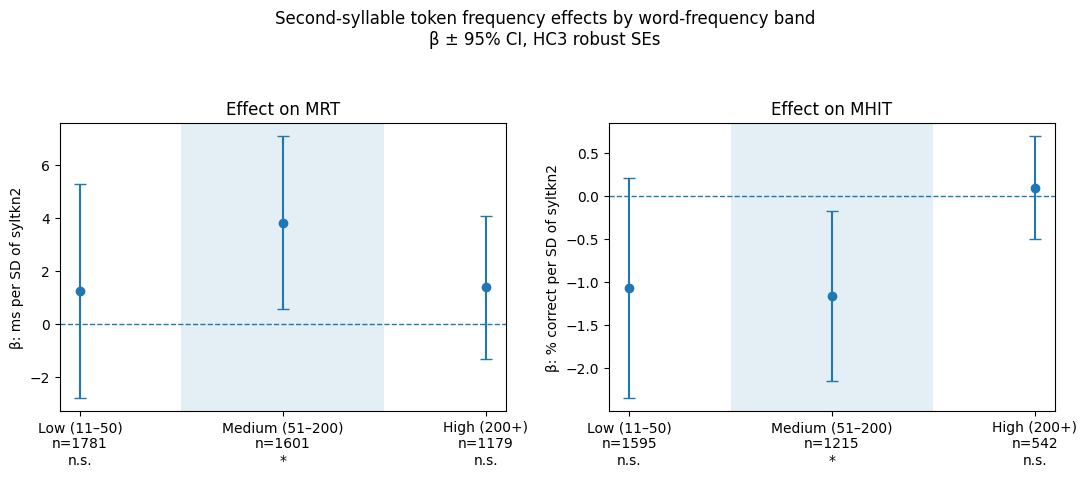

Saved coefficient plot PNG: /content/drive/MyDrive/2026-1/언어심리학/Project Materials/fig_and_tab/figure_band_coefficients_300dpi.png
Saved coefficient plot PDF: /content/drive/MyDrive/2026-1/언어심리학/Project Materials/fig_and_tab/figure_band_coefficients.pdf


In [26]:
plot_df = pd.concat([
    table7[["Band", "DV", "N", "β per SD", "95% CI low", "95% CI high", "p"]],
    table8[["Band", "DV", "N", "β per SD", "95% CI low", "95% CI high", "p"]]
], ignore_index=True)

band_order = ["Low (11–50)", "Medium (51–200)", "High (200+)"]
x = np.arange(len(band_order))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=False)

for ax, dv in zip(axes, ["MRT", "MHIT"]):
    sub = plot_df[plot_df["DV"] == dv].set_index("Band").loc[band_order].reset_index()

    y = sub["β per SD"].values
    yerr_lower = y - sub["95% CI low"].values
    yerr_upper = sub["95% CI high"].values - y

    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="o",
        capsize=4,
        linewidth=1.5
    )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xticks(x)

    labels = []
    for _, row in sub.iterrows():
        p_label = "*" if row["p"] < .05 else "n.s."
        labels.append(f"{row['Band']}\nn={int(row['N'])}\n{p_label}")
    ax.set_xticklabels(labels)

    if dv == "MRT":
        ax.set_title("Effect on MRT")
        ax.set_ylabel("β: ms per SD of syltkn2")
    else:
        ax.set_title("Effect on MHIT")
        ax.set_ylabel("β: % correct per SD of syltkn2")

    # Light highlight for Medium band
    ax.axvspan(0.5, 1.5, alpha=0.12)

fig.suptitle(
    "Second-syllable token frequency effects by word-frequency band\n"
    "β ± 95% CI, HC3 robust SEs",
    y=1.05
)

plt.tight_layout()

png_path = OUT_DIR / "figure_band_coefficients_300dpi.png"
pdf_path = OUT_DIR / "figure_band_coefficients.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved coefficient plot PNG:", png_path)
print("Saved coefficient plot PDF:", pdf_path)

### Optional Frequency Distribution Figure

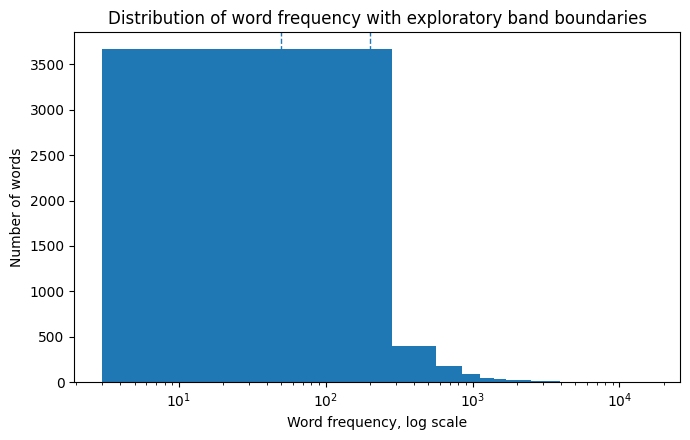

Saved frequency distribution PNG: /content/drive/MyDrive/2026-1/언어심리학/Project Materials/fig_and_tab/figure_frequency_distribution_300dpi.png
Saved frequency distribution PDF: /content/drive/MyDrive/2026-1/언어심리학/Project Materials/fig_and_tab/figure_frequency_distribution.pdf


In [27]:
plt.figure(figsize=(7, 4.5))
plt.hist(df_words["Freq"], bins=60)
plt.axvline(50, linestyle="--", linewidth=1)
plt.axvline(200, linestyle="--", linewidth=1)
plt.xscale("log")
plt.xlabel("Word frequency, log scale")
plt.ylabel("Number of words")
plt.title("Distribution of word frequency with exploratory band boundaries")
plt.tight_layout()

freq_png = OUT_DIR / "figure_frequency_distribution_300dpi.png"
freq_pdf = OUT_DIR / "figure_frequency_distribution.pdf"

plt.savefig(freq_png, dpi=300, bbox_inches="tight")
plt.savefig(freq_pdf, bbox_inches="tight")
plt.show()

print("Saved frequency distribution PNG:", freq_png)
print("Saved frequency distribution PDF:", freq_pdf)